In [5]:
import pandas as pd

# ==========================================
# 1. SETUP & DATA
# ==========================================
og_df = pd.read_csv('all-agx.csv')
df = og_df

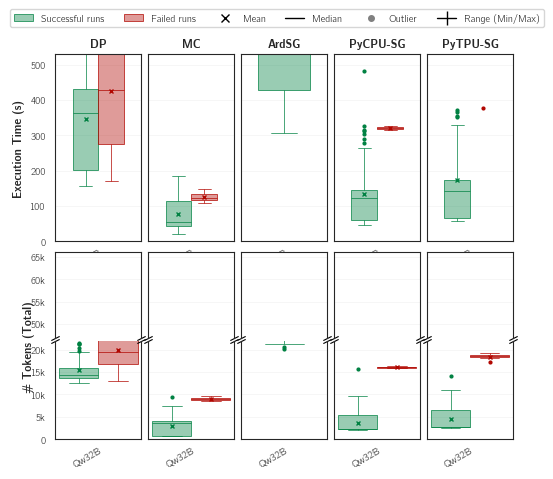

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.ticker import FuncFormatter

# ==========================================
# 2. CONFIGURATION
# ==========================================
# Canonical labels and ordering (single source of truth)
MODEL_LABELS = {
    'gpt-5': 'G5',
    'gpt-4o': 'G4o',
    'gpt-4o-mini': 'G4o-m',
    'phi4': 'Phi4',
    'qwen32': 'Qw32B',
    'qwen14': 'Qw14B',
    'gemma3': 'Ge3',
    'codestral': 'Co22B',
    'codestral-p': 'Co22B-p',
}

PROCESSOR_LABELS = {
    'dp': 'DP',
    'mc': 'MC',
    'sg': 'ArdSG',
    'psg': 'PyCPU-SG',
    'tpusg': 'PyTPU-SG',
}

# Normalize key categorical columns used for grouping/mapping.
for col in ('processor', 'model', 'status'):
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()


processors_present = set(df['processor'])
models_present = set(df['model'])

processors_in_data = [p for p in PROCESSOR_LABELS if p in processors_present]
models_in_data = [m for m in MODEL_LABELS if m in models_present]
model_display_order = [MODEL_LABELS[m] for m in models_in_data]
num_processors = len(processors_in_data)

df['model_display'] = df['model'].map(MODEL_LABELS).fillna(df['model'])

TIME_LIM = (0, 530)
TOK_LIM = (0, 66000)
TOK_BREAK = (22000, 46900)


# Keep token subplot scale aligned across the break: axis heights follow data spans.
latency_ratio = 1.0
token_top_span = TOK_LIM[1] - TOK_BREAK[1]
token_bottom_span = TOK_BREAK[0] - TOK_LIM[0]

token_top_ratio = token_top_span / (token_top_span + token_bottom_span)
token_bottom_ratio = 1 - token_top_ratio

# ==========================================
# 3. STYLE TOKENS (FONTS, SIZES, WEIGHTS, COLORS)
# ==========================================
# FONT_FAMILY = 'Arial'
# TITLE_SIZE = 14
# TITLE_WEIGHT = 'bold'
# LABEL_SIZE = 13
# LABEL_WEIGHT = 'bold'
# LEGEND_SIZE = 12

# ── Fonts ─────────────────────────────────────────────────────────────────────
FONT_FAMILY  = 'CMU Bright'
TITLE_SIZE   = 8       # was 14
TITLE_WEIGHT = 'bold'
LABEL_SIZE   = 8       # was 13
LABEL_WEIGHT = 'bold'
TICK_SIZE    = 7       # NEW — was missing; Elsevier standard floor
LEGEND_SIZE  = 7       # was 12
ZOOM_NOTE_SIZE = 6     # apply to any zoom annotations if added


SUCCESS_EDGE_COLOR = "#008142"
# SUCCESS_FILL_COLOR = "#81D9AA"
SUCCESS_FILL_COLOR = SUCCESS_EDGE_COLOR
FAILURE_EDGE_COLOR = "#B10600"
# FAILURE_FILL_COLOR = "#E2918A"
FAILURE_FILL_COLOR=FAILURE_EDGE_COLOR
GRID_COLOR = '0.88'
MEAN_COLOR = 'black'
MEDIAN_COLOR = 'black'
OUTLIER_COLOR = 'gray'

# BOX_WIDTH = 0.7
# BOX_LINEWIDTH = 1.0
# BOX_FILL_ALPHA = 0.4
# MEAN_MARKER_SIZE = 5
# OUTLIER_MARKER_SIZE = 3
# GRID_LINEWIDTH = 0.6
# GRID_ALPHA = 0.5
# LEGEND_COLUMNS = 6
# DIAG_RATIO = 0.5
# DIAG_MARKERSIZE = 14
# DIAG_COLOR = 'k'
# DIAG_EDGE_WIDTH = 1.3

# ── Box/marker sizes ──────────────────────────────────────────────────────────
BOX_WIDTH           = 0.6    # was 0.7
BOX_LINEWIDTH       = 0.5    # was 1.0
BOX_FILL_ALPHA      = 0.4
MEAN_MARKER_SIZE    = 3      # was 5
OUTLIER_MARKER_SIZE = 2      # was 3
GRID_LINEWIDTH      = 0.4    # was 0.6
GRID_ALPHA          = 0.5
LEGEND_COLUMNS      = 6
# ── Broken-axis diagonal marks ────────────────────────────────────────────────
DIAG_RATIO      = 0.5
DIAG_MARKERSIZE = 6      # was 14 → scaled to small figure
DIAG_COLOR      = 'k'
DIAG_EDGE_WIDTH = 0.8    # was 1.3


STATUS_ORDER = ['success', 'failure']
STATUS_STYLES = {
    'success': {
        'facecolor': SUCCESS_FILL_COLOR,
        'edgecolor': SUCCESS_EDGE_COLOR,
    },
    'failure': {
        'facecolor': FAILURE_FILL_COLOR,
        'edgecolor': FAILURE_EDGE_COLOR,
    },
}
PALETTE = {status: style['facecolor'] for status, style in STATUS_STYLES.items()}
BOXPLOT_COMMON = {
    'x': 'model_display',
    'hue': 'status',
    'hue_order': STATUS_ORDER,
    'order': model_display_order,
    'palette': PALETTE,
    'showmeans': True,
    'meanprops': {
        'marker': 'x',
        'markeredgecolor': MEAN_COLOR,
        'markersize': MEAN_MARKER_SIZE
    },
    'flierprops': {
        'marker': 'o',
        'markersize': OUTLIER_MARKER_SIZE,
        'markerfacecolor': OUTLIER_COLOR,
        'markeredgecolor': OUTLIER_COLOR
    },
    'width': BOX_WIDTH,
    'linewidth': BOX_LINEWIDTH
}

# ==========================================
# 4. PLOTTING (BROKEN TOKEN AXIS FOR AGX)
# ==========================================
sns.set_style('white')
plt.rcParams['font.family'] = FONT_FAMILY
token_fmt = FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")

# Apply globally so seaborn-drawn ticks also inherit correct sizes
plt.rcParams.update({
    'font.family':           FONT_FAMILY,
    'font.size':             TICK_SIZE,        # global fallback
    'axes.labelsize':        LABEL_SIZE,
    'axes.titlesize':        TITLE_SIZE,
    'xtick.labelsize':       TICK_SIZE,        # model name ticks
    'ytick.labelsize':       TICK_SIZE,        # value ticks
    'legend.fontsize':       LEGEND_SIZE,
    'legend.title_fontsize': LABEL_SIZE,
})

def style_axis(ax):
    if ax.get_legend():
        ax.get_legend().remove()
    ax.set_xlabel('')
    ax.grid(
        axis='y',
        color=GRID_COLOR,
        linewidth=GRID_LINEWIDTH,
        linestyle='-',
        alpha=GRID_ALPHA
    )

def patch_x_bounds(ax, patch):
    (x0, _), (x1, _) = ax.transData.inverted().transform(patch.get_extents().get_points())
    return min(x0, x1), max(x0, x1)

def status_for_box_center(box_center):
    nearest_model_idx = min(
        range(len(model_display_order)),
        key=lambda idx: abs(box_center - idx)
    )
    return STATUS_ORDER[0] if box_center <= nearest_model_idx else STATUS_ORDER[1]

def style_boxplot_by_status(ax):
    box_patches = [patch for patch in ax.patches if isinstance(patch, PathPatch)]
    if not box_patches:
        return

    box_specs = []
    for patch in box_patches:
        x0, x1 = patch_x_bounds(ax, patch)
        box_center = (x0 + x1) / 2
        status = status_for_box_center(box_center)
        style = STATUS_STYLES[status]
        fill_rgba = to_rgba(style['facecolor'], BOX_FILL_ALPHA)
        edge_color = style['edgecolor']

        patch.set_facecolor(fill_rgba)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(BOX_LINEWIDTH)

        box_specs.append({
            'center': box_center,
            'x0': x0,
            'x1': x1,
            'edgecolor': edge_color,
        })

    line_tol = BOX_WIDTH * 0.08
    for line in ax.lines:
        xdata = []
        for value in line.get_xdata():
            try:
                numeric_value = float(value)
            except (TypeError, ValueError):
                continue
            if math.isfinite(numeric_value):
                xdata.append(numeric_value)

        if not xdata:
            continue

        x_min = min(xdata)
        x_max = max(xdata)
        x_center = sum(xdata) / len(xdata)

        matches = [
            spec
            for spec in box_specs
            if x_min >= spec['x0'] - line_tol and x_max <= spec['x1'] + line_tol
        ]
        if not matches:
            continue

        spec = min(matches, key=lambda item: abs(x_center - item['center']))
        line.set_color(spec['edgecolor'])
        line.set_markeredgecolor(spec['edgecolor'])
        line.set_markerfacecolor(spec['edgecolor'])

def plot_metric(ax, subset, y_col):
    sns.boxplot(data=subset, y=y_col, ax=ax, **BOXPLOT_COMMON)
    style_boxplot_by_status(ax)

def add_axis_break(ax_top, ax_bottom):
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)

    break_marker_options = dict(
        marker=[(-1, -DIAG_RATIO), (1, DIAG_RATIO)],
        markersize=DIAG_MARKERSIZE,
        linestyle='none',
        color=DIAG_COLOR,
        mec=DIAG_COLOR,
        mew=DIAG_EDGE_WIDTH,
        clip_on=False
    )
    ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **break_marker_options)
    ax_bottom.plot([0, 1], [1, 1], transform=ax_bottom.transAxes, **break_marker_options)

LATENCY_TOKEN_HSPACE = 0.06
TOKEN_BREAK_HSPACE = 0.03

# fig = plt.figure(figsize=(6 * num_processors, 10))
# gs = fig.add_gridspec(
#     nrows=2,
#     ncols=num_processors,
#     height_ratios=[latency_ratio, token_top_ratio + token_bottom_ratio],
#     hspace=LATENCY_TOKEN_HSPACE,
#     wspace=0.04,
#  )
# plt.subplots_adjust(top=0.915)
# =================================================================
# Elsevier double column = 190 mm = 7.48 in [web:3]
# 3-row structure (latency + token-top + token-bottom) + top legend
# Height: ~5.0 in gives each row ~1.5 in of space — sufficient for boxplots
ONE_MM = 1 / 25.4
FIG_W  = 150 * ONE_MM   # 7.48 in — fixed, independent of num_processors
FIG_H  = 127 * ONE_MM   # 5.00 in

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = fig.add_gridspec(
    nrows=2,
    ncols=num_processors,
    height_ratios=[latency_ratio, token_top_ratio + token_bottom_ratio],
    hspace=LATENCY_TOKEN_HSPACE,
    wspace=0.08,            # was 0.04 → slightly wider gap at small size
)
plt.subplots_adjust(top=0.88)   # was 0.915 → leave room for legend


axes = []

for col_idx in range(num_processors):
    latency_ax = fig.add_subplot(
        gs[0, col_idx],
        sharey=axes[0][0] if axes else None
    )
    token_gs = gs[1, col_idx].subgridspec(
        2,
        1,
        height_ratios=[token_top_ratio, token_bottom_ratio],
        hspace=TOKEN_BREAK_HSPACE
    )
    token_top_ax = fig.add_subplot(
        token_gs[0, 0],
        sharey=axes[0][1] if axes else None
    )
    token_bottom_ax = fig.add_subplot(
        token_gs[1, 0],
        sharey=axes[0][2] if axes else None
    )

    axes.append((latency_ax, token_top_ax, token_bottom_ax))

for col_idx, proc in enumerate(processors_in_data):
    subset = df[df['processor'] == proc]

    latency_ax, token_top_ax, token_bottom_ax = axes[col_idx]

    # Latency axis (full range).
    plot_metric(latency_ax, subset, 'latency')

    # Token axes are drawn twice and clipped by two y-ranges to create a broken axis.
    for token_ax in (token_top_ax, token_bottom_ax):
        plot_metric(token_ax, subset, 'total_tokens')

    for ax in (latency_ax, token_top_ax, token_bottom_ax):
        style_axis(ax)
        
    for ax in (latency_ax, token_top_ax, token_bottom_ax):
        style_axis(ax)
        # Vertical separators between each model group
        for xpos in range(len(model_display_order) - 1):
            ax.axvline(
                x=xpos + 0.5,
                color='0.85',
                linewidth=0.4,
                linestyle='--',
                alpha=0.35,
                zorder=0,
            )

    if col_idx > 0:
        for ax in (latency_ax, token_top_ax, token_bottom_ax):
            ax.tick_params(axis='y', labelleft=False)

    latency_ax.set_ylabel(
        'Execution Time (s)' if col_idx == 0 else '',
        fontweight=LABEL_WEIGHT,
        fontsize=LABEL_SIZE
    )
    token_top_ax.set_ylabel('')
    token_bottom_ax.set_ylabel('')

    latency_ax.set_title(
        PROCESSOR_LABELS.get(proc, proc),
        fontsize=TITLE_SIZE,
        weight=TITLE_WEIGHT,
        pad=5
    )

    # latency_ax.tick_params(axis='x', labelbottom=True, pad=0)
    # token_top_ax.tick_params(axis='x', labelbottom=False,  pad=-5)
    # token_bottom_ax.tick_params(axis='x', labelbottom=True, pad=0)
    latency_ax.tick_params(
    axis='x', labelbottom=True, labelsize=TICK_SIZE,
    labelrotation=30, pad=1
    )
    token_top_ax.tick_params(
        axis='x', labelbottom=False, labelsize=TICK_SIZE, pad=-2
    )
    token_bottom_ax.tick_params(
        axis='x', labelbottom=True, labelsize=TICK_SIZE,
        labelrotation=30, pad=1
    )
     # Must come after plot_metric() so get_xticklabels() is not empty
    for ax in (latency_ax, token_bottom_ax):
        plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')

    latency_ax.set_ylim(*TIME_LIM)
    token_top_ax.set_ylim(TOK_BREAK[1], TOK_LIM[1])
    token_bottom_ax.set_ylim(TOK_LIM[0], TOK_BREAK[0])

    token_top_ax.yaxis.set_major_formatter(token_fmt)
    token_bottom_ax.yaxis.set_major_formatter(token_fmt)

    # Hide touching spines and draw diagonal break marks.
    add_axis_break(token_top_ax, token_bottom_ax)

token_top_pos = axes[0][1].get_position()
token_bottom_pos = axes[0][2].get_position()
token_label_x = max(min(token_top_pos.x0, token_bottom_pos.x0) - 0.045, 0.01)
fig.text(
    token_label_x,
    (token_top_pos.y1 + token_bottom_pos.y0) / 2,
    '# Tokens (Total)',
    rotation='vertical',
    va='center',
    ha='center',
    fontweight=LABEL_WEIGHT,
    fontsize=LABEL_SIZE
)

# ==========================================
# 5. CUSTOM LEGEND
# ==========================================
legend_elements = [
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(SUCCESS_FILL_COLOR, BOX_FILL_ALPHA),
        edgecolor=SUCCESS_EDGE_COLOR,
        linewidth=BOX_LINEWIDTH,
        label='Successful runs'
    ),
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(FAILURE_FILL_COLOR, BOX_FILL_ALPHA),
        edgecolor=FAILURE_EDGE_COLOR,
        linewidth=BOX_LINEWIDTH,
        label='Failed runs'
    ),
    Line2D([0], [0], color=MEAN_COLOR, marker='x', linestyle='None', markersize=6, label='Mean'),
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=1, linestyle='-', label='Median'),
    Line2D([0], [0], color=OUTLIER_COLOR, marker='o', linestyle='None', markersize=4, label='Outlier'),
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=1, linestyle='-', marker='|', markersize=10, label='Range (Min/Max)')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=LEGEND_COLUMNS,
    bbox_to_anchor=(0.5, 0.98),
    fontsize=LEGEND_SIZE,
    frameon=True
)

for ext in ('pdf', 'png'):
    plt.savefig(f'figs/box_AGX.{ext}', dpi=500, bbox_inches='tight')
plt.show()


In [7]:
# ==========================================
# EXPORT BOX PLOT STATISTICS
# ==========================================
# Calculate all statistics used in box plots for direct reproduction

def calculate_boxplot_stats(group_data):
    """Calculate all box plot statistics for a group"""
    if len(group_data) == 0:
        return {
            'count': 0,
            'min': None,
            'q1': None,
            'median': None,
            'q3': None,
            'max': None,
            'mean': None,
            'iqr': None,
            'lower_whisker': None,
            'upper_whisker': None,
            'outliers': None,
            'n_outliers': 0
        }
    
    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    
    # Calculate whiskers (1.5 * IQR rule used by matplotlib/seaborn)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Actual whisker positions (min/max within bounds)
    within_bounds = group_data[(group_data >= lower_bound) & (group_data <= upper_bound)]
    lower_whisker = within_bounds.min() if len(within_bounds) > 0 else group_data.min()
    upper_whisker = within_bounds.max() if len(within_bounds) > 0 else group_data.max()
    
    # Outliers (outside whisker bounds)
    outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]
    
    return {
        'count': len(group_data),
        'min': group_data.min(),
        'q1': q1,
        'median': group_data.median(),
        'q3': q3,
        'max': group_data.max(),
        'mean': group_data.mean(),
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'outliers': outliers.tolist(),
        'n_outliers': len(outliers)
    }

# Initialize list to store all statistics
all_stats = []

# Calculate statistics for each metric
metrics_to_export = [
    {'col': 'latency', 'label': 'Execution Time (s)'},
    {'col': 'total_tokens', 'label': '# Tokens (Total)'}
]

for metric in metrics_to_export:
    metric_col = metric['col']
    metric_label = metric['label']
    
    # Group by processor, model, and status
    for processor in df['processor'].unique():
        for model in df['model'].unique():
            for status in ['success', 'failure']:
                # Filter data for this combination
                subset = df[
                    (df['processor'] == processor) & 
                    (df['model'] == model) & 
                    (df['status'] == status)
                ][metric_col].dropna()
                
                # Calculate statistics
                stats = calculate_boxplot_stats(subset)
                
                # Add grouping information
                stats_record = {
                    'metric': metric_col,
                    'processor': processor,
                    'processor_label': PROCESSOR_LABELS.get(processor, processor),
                    'model': model,
                    'model_label': MODEL_LABELS.get(model, model),
                    'status': status,
                    **stats
                }
                
                all_stats.append(stats_record)

# Create DataFrame from statistics
stats_df = pd.DataFrame(all_stats)

# Filter out rows with no data
stats_df = stats_df[stats_df['count'] > 0]

# Drop outliers column for cleaner CSV
stats_df_clean = stats_df.drop(columns=['outliers'])

# Export to single CSV file
output_file = 'cost-time_statistics_AGX.csv'
stats_df_clean.to_csv(output_file, index=False)
print(f"✔ Exported all box plot statistics to: {output_file}")
print(f"  Total records: {len(stats_df_clean)}")
print(f"  Metrics included: latency, total_tokens")

# Display summary
print("\n" + "="*60)
print("STATISTICS SUMMARY")
print("="*60)
print(f"Metrics: {', '.join([m['col'] for m in metrics_to_export])}")
print(f"Processors: {', '.join(stats_df_clean['processor'].unique())}")
print(f"Models: {', '.join(stats_df_clean['model'].unique())}")
print(f"Status values: {', '.join(stats_df_clean['status'].unique())}")
print("\nColumns in exported CSV:")
for col in stats_df_clean.columns:
    print(f"  - {col}")
print("="*60)

# Display sample of statistics
print("\nSample statistics (first few rows):")
display(stats_df_clean.head(10))

✔ Exported all box plot statistics to: cost-time_statistics_AGX.csv
  Total records: 18
  Metrics included: latency, total_tokens

STATISTICS SUMMARY
Metrics: latency, total_tokens
Processors: mc, psg, sg, dp, tpusg
Models: qwen32
Status values: success, failure

Columns in exported CSV:
  - metric
  - processor
  - processor_label
  - model
  - model_label
  - status
  - count
  - min
  - q1
  - median
  - q3
  - max
  - mean
  - iqr
  - lower_whisker
  - upper_whisker
  - n_outliers

Sample statistics (first few rows):


,metric,processor,processor_label,model,model_label,status,count,min,q1,median,q3,max,mean,iqr,lower_whisker,upper_whisker,n_outliers
0,latency,mc,MC,qwen32,Qw32B,success,56,19.73,42.6025,54.275,112.4075,183.29,75.780000,69.8050,19.73,183.29,0
1,latency,mc,MC,qwen32,Qw32B,failure,4,108.65,115.5725,122.935,133.1450,148.61,125.782500,17.5725,108.65,148.61,0
2,latency,psg,PyCPU-SG,qwen32,Qw32B,success,57,46.90,59.3400,122.750,145.3900,481.26,134.805614,86.0500,46.90,263.66,7
3,latency,psg,PyCPU-SG,qwen32,Qw32B,failure,3,313.89,317.2750,320.660,323.0150,325.37,319.973333,5.7400,313.89,325.37,0
5,latency,sg,ArdSG,qwen32,Qw32B,failure,60,305.43,427.9975,647.750,1030.4800,1298.45,723.668667,602.4825,305.43,1298.45,0
6,latency,dp,DP,qwen32,Qw32B,success,46,157.04,200.6325,362.530,432.3200,737.26,345.962391,231.6875,157.04,737.26,0
7,latency,dp,DP,qwen32,Qw32B,failure,14,171.67,275.4525,427.715,568.1725,694.99,425.102143,292.7200,171.67,694.99,0
8,latency,tpusg,PyTPU-SG,qwen32,Qw32B,success,53,56.20,65.6600,143.000,173.8100,640.43,173.976038,108.1500,56.20,328.39,7
9,latency,tpusg,PyTPU-SG,qwen32,Qw32B,failure,7,377.55,777.0300,851.100,881.1400,909.20,779.170000,104.1100,744.06,909.20,1
10,total_tokens,mc,MC,qwen32,Qw32B,success,56,694.00,743.7500,3591.000,4011.7500,9345.00,2882.089286,3268.0000,694.00,7522.00,1
